**Goal of this notebook:**
1. Build a single-neuron *Perceptron* from scratch in NumPy.
2. Train it on the **AND** gate
3. Train it on the **OR** gate
4. Train it on the **XOR** gate — **must fail**. Seeing the failure  is the point.
5. Plot decision boundaries to *see* why XOR is impossible for a single line.

## 1. Setup

Just NumPy + Matplotlib. No deep-learning framework yet — we want to *see* the math.

In [ ]:
%%writefile requirements.txt
matplotlib

In [1]:
!pip install matplotlib

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) # reproducibility

print('numpy', np.__version__)

numpy 2.0.2


## 2. The Perceptron - from scratch

Recall the formula:

```
ŷ = 1   if  (w · x + b) ≥ 0
  = 0   otherwise
```

Update rule (Rosenblatt, 1958):

```
for each (x, y):
    error = y - ŷ
    w ← w + lr · error · x
    b ← b + lr · error
```

Read the class below line-by-line. Every line maps to one of those two formulas.

In [4]:
class Perceptron:
    def __init__(self, n_inputs, lr=0.1, epochs=20):
        # one weight per input feature, plus a single bias
        self.w = np.zeros(n_inputs)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs

    def _step(self, z):
        # the original perceptron's hard threshold activation
        return 1 if z >= 0 else 0

    def predict(self, x):
        return self._step(np.dot(x, self.w) + self.b)

    def fit(self, X, y):
        history = []  # number of mistakes per epoch — we want this to reach 0
        for ep in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred  # +1, 0, or -1
                self.w += self.lr * error * xi
                self.b += self.lr * error
                if error != 0:
                    errors += 1
            history.append(errors)
        return history

    def accuracy(self, X, y):
        preds = np.array([self.predict(xi) for xi in X])
        return (preds == y).mean()

## 3. Train on AND gate (linearly separable → should succeed)

AND truth table: output is 1 only when both inputs are 1.

Expected outcome: the `errors_per_epoch` list reaches 0, accuracy = 1.0.

In [5]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

p_and = Perceptron(n_inputs=2, lr=0.1, epochs=20)
hist_and = p_and.fit(X_and, y_and)

print('Errors per epoch:', hist_and)
print(f'Final weights: {p_and.w}, bias: {p_and.b:.2f}')
print(f'Accuracy: {p_and.accuracy(X_and, y_and):.2f}')
print()
print('Truth table check:')
for xi, yi in zip(X_and, y_and):
    print(f'  input {xi}  target {yi}  predicted {p_and.predict(xi)}')

Errors per epoch: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Final weights: [0.2 0.1], bias: -0.20
Accuracy: 1.00

Truth table check:
  input [0 0]  target 0  predicted 0
  input [0 1]  target 0  predicted 0
  input [1 0]  target 0  predicted 0
  input [1 1]  target 1  predicted 1


## 4. Train on OR gate (also linearly separable → should succeed)

In [6]:
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

p_or = Perceptron(n_inputs=2, lr=0.1, epochs=20)
hist_or = p_or.fit(X_or, y_or)

print('Errors per epoch:', hist_or)
print(f'Final weights: {p_or.w}, bias: {p_or.b:.2f}')
print(f'Accuracy: {p_or.accuracy(X_or, y_or):.2f}')

Errors per epoch: [2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Final weights: [0.1 0.1], bias: -0.10
Accuracy: 1.00


## 5. Train on XOR gate — **watch it fail**

XOR: output is 1 only when inputs *differ*.

What we expect:
- `errors_per_epoch` will **never reach 0**, no matter how many epochs.
- Accuracy will be stuck around 0.50 (chance level).
- This is **not a bug**. It's the famous theoretical limit of a single perceptron — proven by Minsky & Papert in 1969.

In [7]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

p_xor = Perceptron(n_inputs=2, lr=0.1, epochs=200)  # try 10× more epochs to be fair
hist_xor = p_xor.fit(X_xor, y_xor)

print('Errors per epoch (last 20):', hist_xor[-20:])
print(f'Final weights: {p_xor.w}, bias: {p_xor.b:.2f}')
print(f'Accuracy: {p_xor.accuracy(X_xor, y_xor):.2f}')
print()
print('Notice the errors never settle to 0 — the perceptron oscillates forever.')

Errors per epoch (last 20): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Final weights: [-0.1  0. ], bias: 0.00
Accuracy: 0.50

Notice the errors never settle to 0 — the perceptron oscillates forever.


## 6. Visualize the decision boundary

A picture makes the failure obvious. We'll plot the 4 data points and shade the region the perceptron predicts as class 1.

- **AND / OR**: a clean diagonal slash separates classes. Perceptron handles it.
- **XOR**: the 1s and 0s sit at *diagonal corners*. No single straight line can separate them — and our perceptron can only ever draw a single straight line.

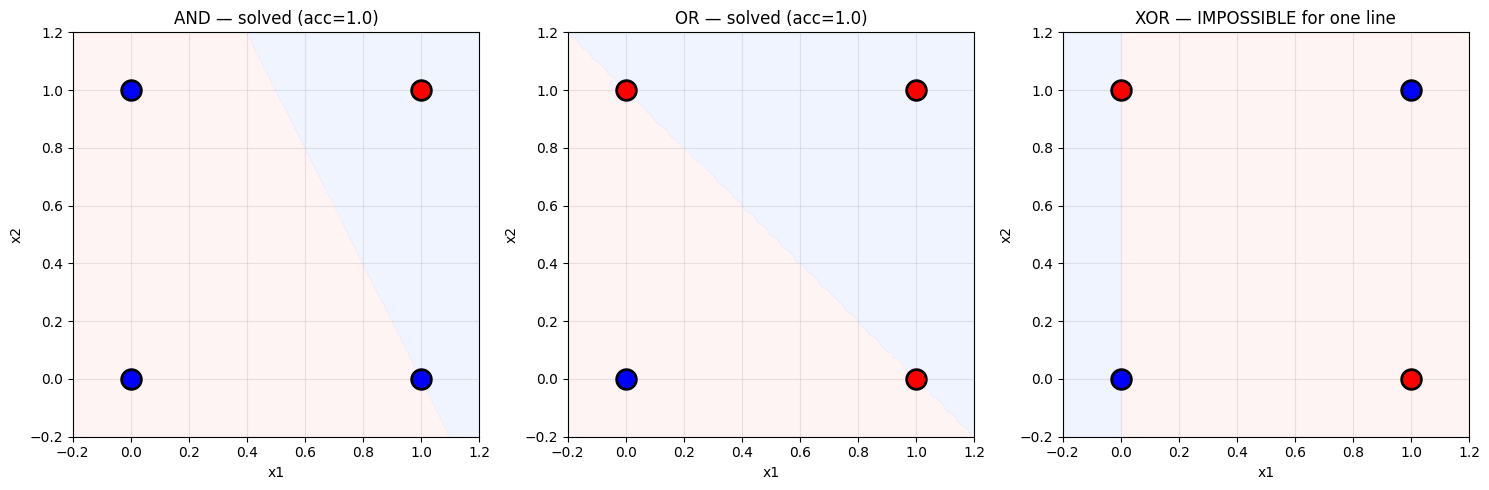

In [9]:
def plot_decision(ax, model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = np.array([model.predict(p) for p in grid]).reshape(xx.shape)
    ax.contourf(xx, yy, preds, alpha=0.3, levels=[-0.1, 0.5, 1.1], colors=['#fdd', '#cdf'])
    for xi, yi in zip(X, y):
        ax.scatter(xi[0], xi[1], c='red' if yi == 1 else 'blue', s=200,
                   edgecolors='black', linewidths=2, zorder=10)
    ax.set_title(title)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_xlim(-0.2, 1.2); ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_decision(axes[0], p_and, X_and, y_and, 'AND — solved (acc=1.0)')
plot_decision(axes[1], p_or,  X_or,  y_or,  'OR — solved (acc=1.0)')
plot_decision(axes[2], p_xor, X_xor, y_xor, 'XOR — IMPOSSIBLE for one line')
plt.tight_layout()
plt.show()

## 7. Convergence plot — visualize learning over epochs

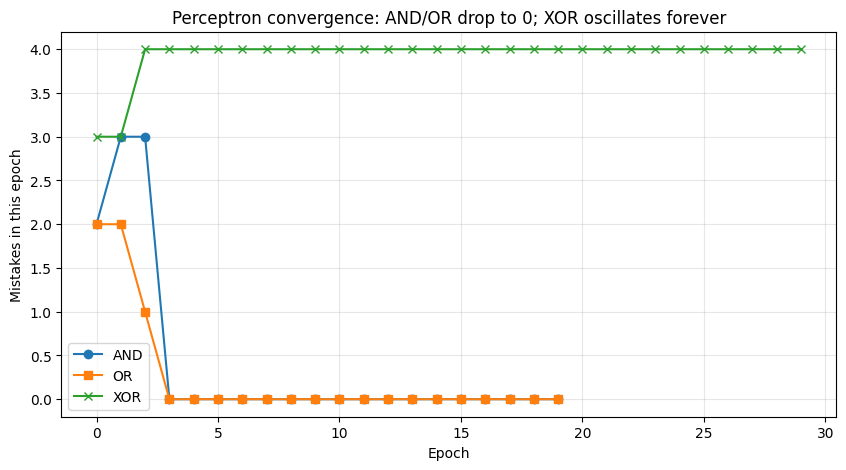

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_and[:30], label='AND', marker='o')
ax.plot(hist_or[:30],  label='OR',  marker='s')
ax.plot(hist_xor[:30], label='XOR', marker='x')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mistakes in this epoch')
ax.set_title('Perceptron convergence: AND/OR drop to 0; XOR oscillates forever')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 8. So what?

This is *exactly* the result that froze AI research for ~15 years (the first AI winter). The fix already existed in principle:

> *Stack two perceptrons. The first one carves the plane into 2 half-planes; the second one combines them. With 2 perceptrons + a non-linear activation, XOR is solvable.*

But until **backpropagation** was popularized in 1986, nobody knew how to train such a multi-layer network.

Before moving on, scroll back through this notebook and try to answer:

1. Where exactly in the `Perceptron` class does the *learning rule* live?
2. If you set `lr=10.0`, what happens to AND? *(Try it!)*
3. If you initialize `self.w = np.random.randn(n_inputs)` instead of zeros, does AND still converge?



### Exploring `lr=10.0` for the AND gate

In [14]:
p_and_lr10 = Perceptron(n_inputs=2, lr=10.0, epochs=20)
hist_and_lr10 = p_and_lr10.fit(X_and, y_and)

print('Errors per epoch (lr=10.0):', hist_and_lr10)
print(f'Final weights (lr=10.0): {p_and_lr10.w}, bias: {p_and_lr10.b:.2f}')
print(f'Accuracy (lr=10.0): {p_and_lr10.accuracy(X_and, y_and):.2f}')


Errors per epoch (lr=10.0): [2, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Final weights (lr=10.0): [20. 10.], bias: -30.00
Accuracy (lr=10.0): 1.00


Observation: With a larger learning rate, the perceptron still converges, but often much faster, reaching 0 errors within the first few epochs. However, a very large learning rate can sometimes lead to instability or oscillation if the error surface is more complex.

3.  **If you initialize `self.w = np.random.randn(n_inputs)` instead of zeros, does AND still converge?**
    To test this without modifying the original `Perceptron` class, I will define a new class `PerceptronRandomInit` that initializes weights randomly.

In [15]:
class PerceptronRandomInit(Perceptron):
    def __init__(self, n_inputs, lr=0.1, epochs=20):
        super().__init__(n_inputs, lr, epochs)
        # Initialize weights randomly instead of zeros
        self.w = np.random.randn(n_inputs)

print('Defined PerceptronRandomInit class.')

Defined PerceptronRandomInit class.


### Exploring random weight initialization for the AND gate

In [16]:
p_and_rand = PerceptronRandomInit(n_inputs=2, lr=0.1, epochs=20)
hist_and_rand = p_and_rand.fit(X_and, y_and)

print('Errors per epoch (random init):', hist_and_rand)
print(f'Final weights (random init): {p_and_rand.w}, bias: {p_and_rand.b:.2f}')
print(f'Accuracy (random init): {p_and_rand.accuracy(X_and, y_and):.2f}')


Errors per epoch (random init): [3, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Final weights (random init): [0.44768854 0.82302986], bias: -1.00
Accuracy (random init): 1.00


Observation: Even with random initial weights, the AND gate is linearly separable, so the perceptron should still converge to a solution. The number of epochs required might vary each run due to the randomness, but it should eventually reach 0 errors and 1.0 accuracy.